In [ ]:
import numpy as np
import pandas as pd
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


THEME = 'BrBG'

# -------------------------------------------------
# 1. Your original parameters
# -------------------------------------------------
var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# True loadings (7 x 5)
Lambda_true = np.array([
    [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653],
    [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640],
    [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878],
    [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300],
    [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474],
    [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435],
    [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040]
])

# VAR(2) coefficients (5 x 5)
Phi1 = np.array([
    [ 0.069570, -0.045041, -0.032271, -0.126121, -0.116237],
    [ 0.123517, -0.006882,  0.033199, -0.266336, -0.075593],
    [ 0.027233,  0.014420, -0.000103, -0.045385, -0.024730],
    [ 0.198330,  0.008947,  0.016066, -0.222132, -0.061226],
    [-0.032710, -0.032482,  0.001286,  0.015577, -0.016760]
])

Phi2 = np.array([
    [ 0.013774, -0.033803,  0.025312, -0.071823,  0.012382],
    [ 0.042048, -0.043486,  0.014998, -0.043731,  0.009972],
    [ 0.011989, -0.002305, -0.016781, -0.016861, -0.030828],
    [ 0.018717, -0.000719, -0.003339, -0.048658,  0.031319],
    [ 0.003668,  0.029666,  0.001740,  0.012825, -0.005191]
])

# -------------------------------------------------
# 2. Simulate the true factors from VAR(2)
# -------------------------------------------------
np.random.seed(42)
T = 4000
burn = 500
F = np.zeros((T, 5))

for t in range(2, T):
    F[t] = Phi1 @ F[t-1] + Phi2 @ F[t-2] + np.random.randn(5)

F = F[burn:]  # stationary sample

# -------------------------------------------------
# 3. Generate observed data (no idiosyncratic noise for verification)
#    Y = F @ Lambda_true.T
# -------------------------------------------------
idiosyncratic_std = 0.0 # Blev sämre av noise...
noise = np.random.randn(len(F), 7) * idiosyncratic_std

Y = F @ Lambda_true.T + noise
df_sim = pd.DataFrame(Y, columns=var_names)


# Z-score to match your original preprocessing
df_sim = pd.DataFrame(StandardScaler().fit_transform(df_sim), columns=var_names)

# -------------------------------------------------
# 4. Re-extract factors via PCA (as you presumably did originally)
# -------------------------------------------------
pca = PCA(n_components=5)
F_est = pca.fit_transform(df_sim)          # (T x 5) scores
Lambda_est = pca.components_.T             # (7 x 5) loadings

# -------------------------------------------------
# 5. PROCRUSTES ALIGNMENT (the missing step)
# -------------------------------------------------
# Find rotation matrix R that minimizes ||F - F_est @ R||_F
R, _ = orthogonal_procrustes(F_est, F)     # Note: (estimated, target)

# Apply rotation to factors and loadings
F_aligned = F_est @ R
Lambda_aligned = Lambda_est @ R

# Fix sign ambiguity (flip signs to match original where possible)
signs = np.sign(np.diag(Lambda_aligned.T @ Lambda_true))
Lambda_aligned = Lambda_aligned * signs
F_aligned = F_aligned * signs

# -------------------------------------------------
# 6. Compare
# -------------------------------------------------
print("Original Loadings:")
print(pd.DataFrame(Lambda_true, index=var_names, columns=[f"F{i}" for i in range(5)]))
print("\nAligned Simulated Loadings:")
print(pd.DataFrame(np.round(Lambda_aligned, 6), index=var_names, columns=[f"F{i}" for i in range(5)]))

# Check correlation between true and aligned factors (should be ~1)
print("\nCorrelation between true and aligned factors:")
print(np.diag(np.corrcoef(F.T, F_aligned.T)[:5, 5:]).round(4))

Original Loadings:
                    F0        F1        F2        F3        F4
gurkor       -0.460493  0.431975  0.226305 -0.218470 -0.041653
guitars       0.494112  0.212170  0.095774 -0.260540 -0.236640
slingshots    0.441043  0.204170  0.094476 -0.485899 -0.347878
stocks        0.045350 -0.378985  0.920457  0.082476 -0.006300
sugar         0.203079  0.539617  0.140728  0.759331 -0.240474
water        -0.469721  0.408214  0.206995 -0.237389 -0.099435
tranquillity  0.292140  0.353894  0.144209 -0.092477  0.868040

Aligned Simulated Loadings:
                    F0        F1        F2        F3        F4
gurkor       -0.452679  0.439122  0.226908 -0.222000 -0.033200
guitars       0.547566  0.263266  0.115445 -0.253596 -0.251113
slingshots    0.396687  0.165255  0.078466 -0.483499 -0.334732
stocks        0.044010 -0.377329  0.921067  0.083586 -0.006065
sugar         0.181144  0.532522  0.135732  0.760672 -0.236891
water        -0.471080  0.403705  0.205789 -0.242737 -0.107447
tranqui

Original returns standard deviations:
gurkor          0.003952
guitars         0.014977
slingshots      0.014880
stocks          0.014901
sugar           0.015080
water           0.003506
tranquillity    0.012763
dtype: float64

Simulated standardized returns (should be ~N(0,1)):
gurkor          0.726939
guitars         0.677000
slingshots      0.791636
stocks          1.019912
sugar           1.094608
water           0.729055
tranquillity    0.991912
dtype: float64

Simulated returns volatilities (should match original):
gurkor          0.003952
guitars         0.014977
slingshots      0.014880
stocks          0.014901
sugar           0.015080
water           0.003506
tranquillity    0.012763
dtype: float64


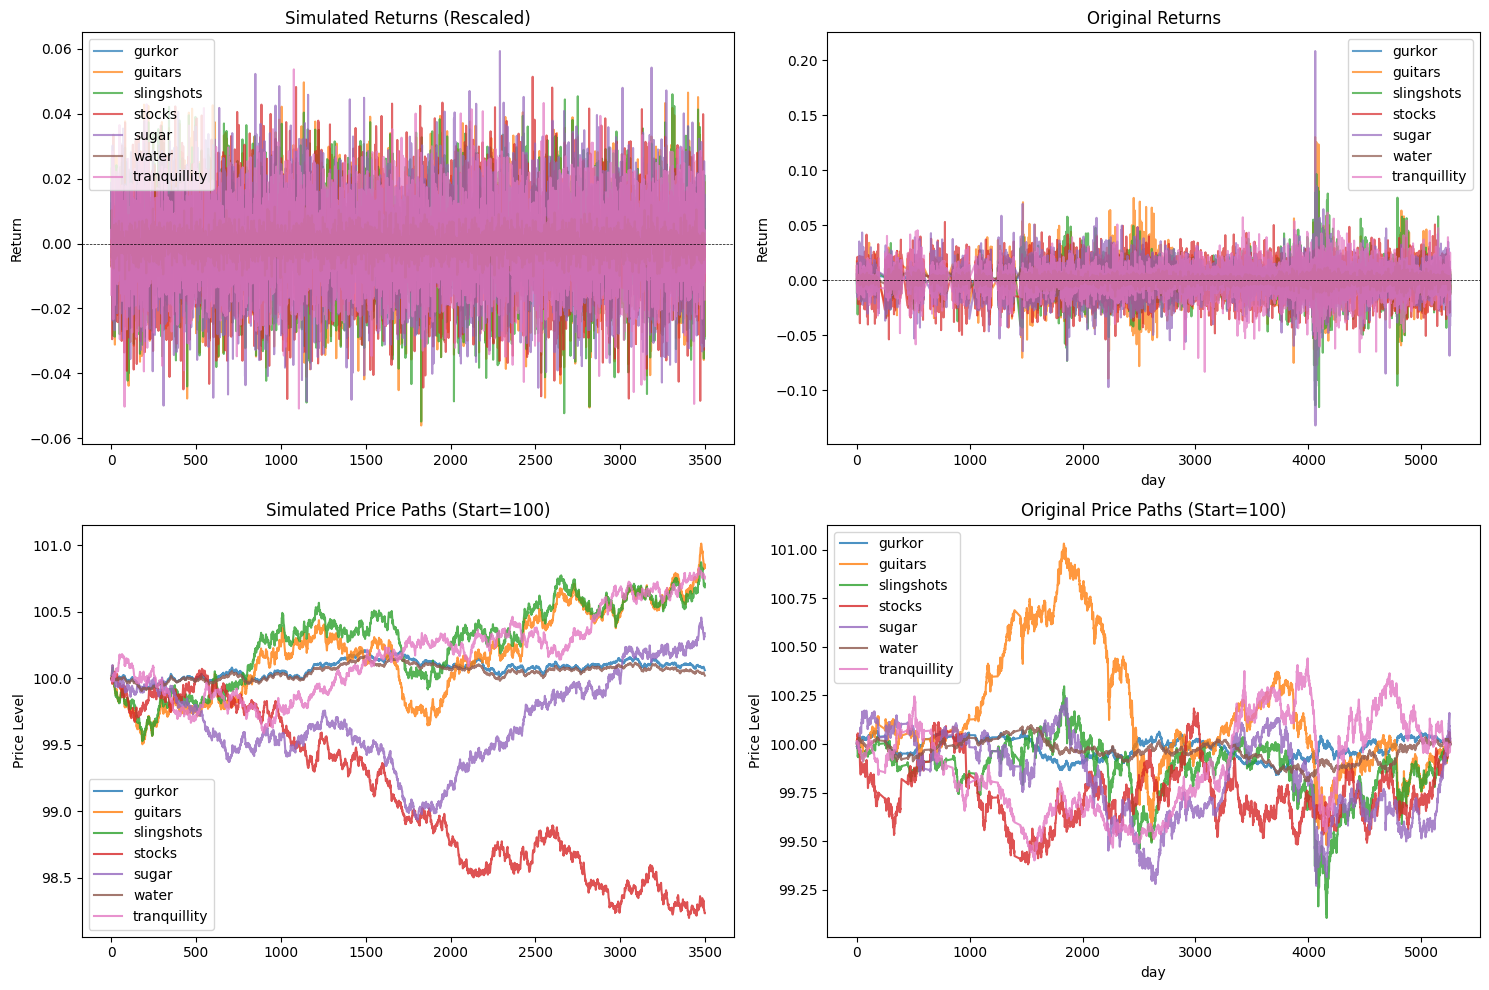


Volatility comparison (Original vs Simulated):
              Original  Simulated  Ratio
gurkor          0.0040     0.0040    1.0
guitars         0.0150     0.0150    1.0
slingshots      0.0149     0.0149    1.0
stocks          0.0149     0.0149    1.0
sugar           0.0151     0.0151    1.0
water           0.0035     0.0035    1.0
tranquillity    0.0128     0.0128    1.0


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import orthogonal_procrustes
from sklearn.decomposition import PCA

var_names = ['gurkor', 'guitars', 'slingshots', 'stocks', 'sugar', 'water', 'tranquillity']

# -------------------------------------------------
# 1. Load original data and get scaling parameters
# -------------------------------------------------
df_og = pd.read_csv('../data/spiff_data-2.csv')
df_og = df_og.replace(1000, np.nan)
df_original = df_og.drop(columns=['Unnamed: 0']).set_index('day')

# Calculate returns (price ratios Pt/Pt-1) as you did originally
df_og_returns = (df_original / df_original.shift(1) - 1).dropna() 
original_mean = df_og_returns.mean()
df_og_returns = df_og_returns - original_mean
# Get standard deviations (for rescaling the simulation back)
original_stds = df_og_returns.std()
print("Original returns standard deviations:")
print(original_stds)

# -------------------------------------------------
# 2. Define your factor model parameters
# # -------------------------------------------------
# Lambda_true = np.array([
#     [-0.460493,  0.431975,  0.226305, -0.218470, -0.041653],
#     [ 0.494112,  0.212170,  0.095774, -0.260540, -0.236640],
#     [ 0.441043,  0.204170,  0.094476, -0.485899, -0.347878],
#     [ 0.045350, -0.378985,  0.920457,  0.082476, -0.006300],
#     [ 0.203079,  0.539617,  0.140728,  0.759331, -0.240474],
#     [-0.469721,  0.408214,  0.206995, -0.237389, -0.099435],
#     [ 0.292140,  0.353894,  0.144209, -0.092477,  0.868040]
# ])

# Phi1 = np.array([
#     [ 0.069570, -0.045041, -0.032271, -0.126121, -0.116237],
#     [ 0.123517, -0.006882,  0.033199, -0.266336, -0.075593],
#     [ 0.027233,  0.014420, -0.000103, -0.045385, -0.024730],
#     [ 0.198330,  0.008947,  0.016066, -0.222132, -0.061226],
#     [-0.032710, -0.032482,  0.001286,  0.015577, -0.016760]
# ])

# Phi2 = np.array([
#     [ 0.013774, -0.033803,  0.025312, -0.071823,  0.012382],
#     [ 0.042048, -0.043486,  0.014998, -0.043731,  0.009972],
#     [ 0.011989, -0.002305, -0.016781, -0.016861, -0.030828],
#     [ 0.018717, -0.000719, -0.003339, -0.048658,  0.031319],
#     [ 0.003668,  0.029666,  0.001740,  0.012825, -0.005191]
# ])

# # -------------------------------------------------
# # 3. Simulate VAR(2) factors (same as your original)
# # -------------------------------------------------
# np.random.seed(42)
# T = 4000
# burn = 500
# F = np.zeros((T, 5))

# for t in range(2, T):
#     F[t] = Phi1 @ F[t-1] + Phi2 @ F[t-2] + np.random.randn(5)

# F = F[burn:]  # Stationary sample

# -------------------------------------------------
# 4. Reconstruct standardized returns from factors
# -------------------------------------------------
# This gives you z-scored returns (mean 0, std 1) because factors are N(0,1) and loadings are orthogonal
Y_std = Y
df_recon_std = pd.DataFrame(Y_std, columns=var_names)

print("\nSimulated standardized returns (should be ~N(0,1)):")
print(df_recon_std.std())
# -------------------------------------------------
# 5. STANDARDIZE simulated returns first, then rescale to original volatility
# -------------------------------------------------
# Y_std currently has variance = sum of squared loadings per row (not 1)
# Standardize to actually get N(0,1) - this preserves correlations
Y_current_stds = pd.DataFrame(Y, columns=var_names).std()

df_returns_sim = pd.DataFrame(Y, columns=var_names).multiply(
    original_stds / Y_current_stds, axis=1
)
# Now rescale by original standard deviations

print("\nSimulated returns volatilities (should match original):")
print(df_returns_sim.std())

# -------------------------------------------------
# 6. Accumulate to price series (start at 100)
# -------------------------------------------------
start_value = 100
df_prices_sim = start_value + df_returns_sim.cumsum()
df_prices_original = start_value + df_og_returns.cumsum()

# -------------------------------------------------
# 7. Plot comparison
# -------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Simulated returns (rescaled to original volatility)
df_returns_sim.plot(ax=axes[0,0], alpha=0.7, title='Simulated Returns (Rescaled)')
axes[0,0].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,0].set_ylabel('Return')

# Plot 2: Original returns
df_og_returns.plot(ax=axes[0,1], alpha=0.7, title='Original Returns')
axes[0,1].axhline(0, color='black', linestyle='--', linewidth=0.5)
axes[0,1].set_ylabel('Return')

# Plot 3: Simulated prices (cumsum)
df_prices_sim.plot(ax=axes[1,0], alpha=0.8, title='Simulated Price Paths (Start=100)')
axes[1,0].set_ylabel('Price Level')

# Plot 4: Original prices (cumsum)
df_prices_original.plot(ax=axes[1,1], alpha=0.8, title='Original Price Paths (Start=100)')
axes[1,1].set_ylabel('Price Level')

plt.tight_layout()
plt.show()

# -------------------------------------------------
# 8. Validation: Volatility comparison
# -------------------------------------------------
print("\nVolatility comparison (Original vs Simulated):")
comparison = pd.DataFrame({
    'Original': original_stds,
    'Simulated': df_returns_sim.std(),
    'Ratio': df_returns_sim.std() / original_stds
})
print(comparison.round(4))

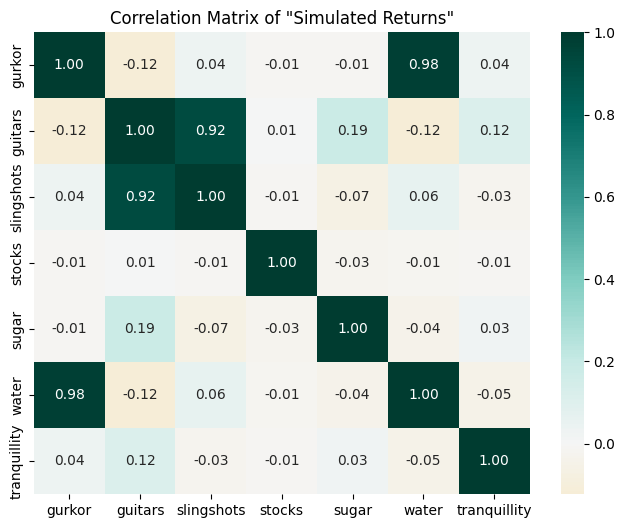

=============================== SIMULATED RETURNS PCA ================================


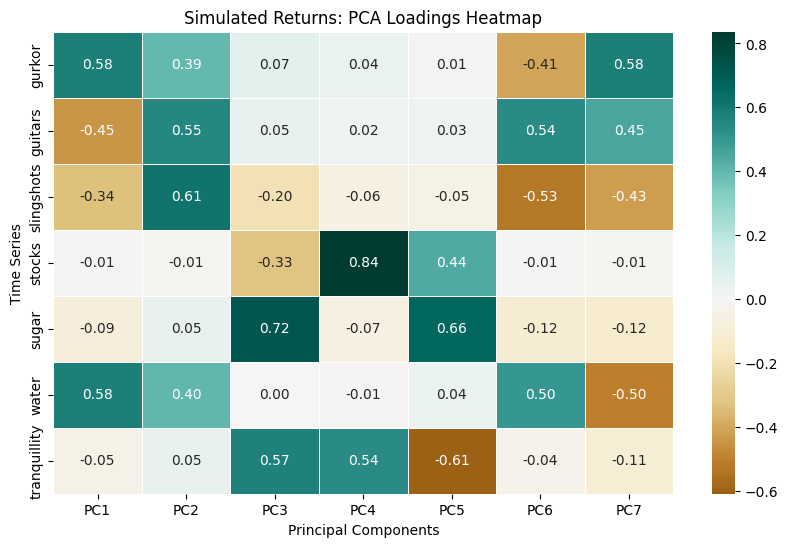

Explained Variance Ratio per Component:
PC1: 0.2922 (29.22%)
PC2: 0.2695 (26.95%)
PC3: 0.1521 (15.21%)
PC4: 0.1428 (14.28%)
PC5: 0.1381 (13.81%)
PC6: 0.0027 (0.27%)
PC7: 0.0026 (0.26%)

Cumulative Variance Explained by top 3 components: 71.39%


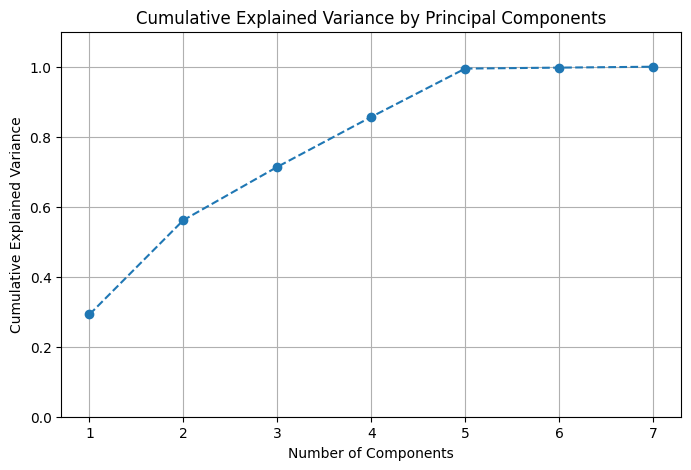

=== PRINCIPAL COMPONENT DRIVERS ===

PC1 is primarily driven by:
  gurkor          | Weight:  0.5818 | 🟢 Positive
  water           | Weight:  0.5791 | 🟢 Positive
  guitars         | Weight: -0.4509 | 🔴 Negative
  slingshots      | Weight: -0.3357 | 🔴 Negative

PC2 is primarily driven by:
  slingshots      | Weight:  0.6141 | 🟢 Positive
  guitars         | Weight:  0.5502 | 🟢 Positive
  water           | Weight:  0.4007 | 🟢 Positive
  gurkor          | Weight:  0.3931 | 🟢 Positive

PC3 is primarily driven by:
  sugar           | Weight:  0.7244 | 🟢 Positive
  tranquillity    | Weight:  0.5664 | 🟢 Positive
  stocks          | Weight: -0.3266 | 🔴 Negative


--- Simulated Returns Variance Explained ---
Top 3 components explain: 71.39%

PCA Loadings (How much each series contributes to each PC):
                   PC1       PC2       PC3       PC4       PC5       PC6  \
gurkor        0.581751  0.393121  0.069545  0.041466  0.009279 -0.408517   
guitars      -0.450866  0.550210  0.049640  0

In [23]:

import seaborn as sns

# Calculate Returns and align metadata

# --- 2. CORRELATION ANALYSIS ---
plt.figure(figsize=(8, 6))
sns.heatmap(df_returns_sim.corr(), annot=True, cmap=THEME, center=0, fmt=".2f")
plt.title('Correlation Matrix of "Simulated Returns"')
plt.show()

# --- 3. PCA FUNCTION ---
# Building a function keeps your code DRY (Don't Repeat Yourself) 
# and prevents variable overwriting.
def run_and_plot_pca(data, title_prefix):
    # Standardize
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)
    
    # Fit PCA
    pca = PCA()
    pca.fit(scaled_data)
    
    # Loadings extraction
    loadings_df = pd.DataFrame(
        pca.components_.T, 
        columns=[f'PC{i+1}' for i in range(pca.n_components_)], 
        index=data.columns
    )
    
    # Plot Heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(loadings_df, annot=True, cmap=THEME, center=0, fmt=".2f", linewidths=0.5)
    plt.title(f'{title_prefix}: PCA Loadings Heatmap')
    plt.xlabel('Principal Components')
    plt.ylabel('Time Series')
    plt.show()

    # explained var
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    print("Explained Variance Ratio per Component:")
    for i, var in enumerate(explained_variance):
        print(f"PC{i+1}: {var:.4f} ({var*100:.2f}%)")

    print(f"\nCumulative Variance Explained by top 3 components: {cumulative_variance[2]*100:.2f}%")

    # Plot the Scree Plot
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, 8), cumulative_variance, marker='o', linestyle='--')
    plt.title('Cumulative Explained Variance by Principal Components')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.grid(True)
    plt.ylim(0, 1.1)
    plt.show()

    print("=== PRINCIPAL COMPONENT DRIVERS ===")
    for pc in ['PC1', 'PC2', 'PC3']:
        print(f"\n{pc} is primarily driven by:")
        
        # Sort the features by their absolute contribution to this PC
        sorted_features = loadings_df[pc].abs().sort_values(ascending=False)
        
        for feature, abs_weight in sorted_features.items():
            actual_weight = loadings_df.loc[feature, pc]
            
            # Threshold: We only print features that have a meaningful impact (e.g., > 0.3)
            # Loadings are constrained between -1 and 1.
            if abs_weight > 0.25:
                direction = "🟢 Positive" if actual_weight > 0 else "🔴 Negative"
                print(f"  {feature:<15} | Weight: {actual_weight:>7.4f} | {direction}")

    print("\n" + "="*35 + "\n")
    
    # Variance Explained
    cumulative_var = np.cumsum(pca.explained_variance_ratio_)
    print(f"--- {title_prefix} Variance Explained ---")
    print(f"Top 3 components explain: {cumulative_var[2]*100:.2f}%\n")

    loadings = pd.DataFrame(
    pca.components_.T,  # Transpose the matrix
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=df_returns_sim.columns # Your original 7 column names
)

    print("PCA Loadings (How much each series contributes to each PC):")
    print(loadings)
    
    return pca, loadings_df

# --- 4. EXECUTE COMPARISON ---

print(80*"=")
print(f'{31* '='} SIMULATED RETURNS PCA {32* '='}')
print(80*"=")
pca_returns, loadings_returns = run_and_plot_pca(df_returns_sim, "Simulated Returns")